In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import os
import sys
from collections import Counter
import gget
import scipy
from sklearn import preprocessing
import umap

import scanpy as sc
import scanpy.external as sce
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

sc.settings.verbosity = 3

2024-01-17 13:09:56.345837: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-01-17 13:09:56.509502: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-01-17 13:09:58.213243: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2024-01-17 13:09:58.213332: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such 

RuntimeError: module compiled against API version 0xf but this version of numpy is 0xe

In [2]:
umap.__file__

'/home/cstansbu/.local/lib/python3.9/site-packages/umap/__init__.py'

# Load our data

In [3]:
# fpath = "/scratch/indikar_root/indikar1/cstansbu/all_scHSC_run3/scanpy/anndata_distance.h5ad"
# fpath = "/scratch/indikar_root/indikar1/cstansbu/all_scHSC_run4/scanpy/anndata_distance.h5ad"
fpath = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/scanpy/anndata_distance.h5ad"

adata = sc.read(fpath, cache=False)
adata.obs['cluster_name'] = adata.obs['clusters'].apply(lambda x: f"C{int(x) + 1}")
adata

/home/cstansbu/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 8475 × 14753
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'clusters', 'cluster_name', 'UMAP 1', 'UMAP 2', 'Fibroblast_mean', 'Fibroblast_max', 'Fibroblast_argmax', 'Fibroblast_highest_exp', 'HSC_mean', 'HSC_max', 'HSC_argmax', 'HSC_highest_exp'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_name_colors', 'clusters_colors', 'clusters_sizes', 'dendrogram_cluster_name', 'hvg', 'leiden', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

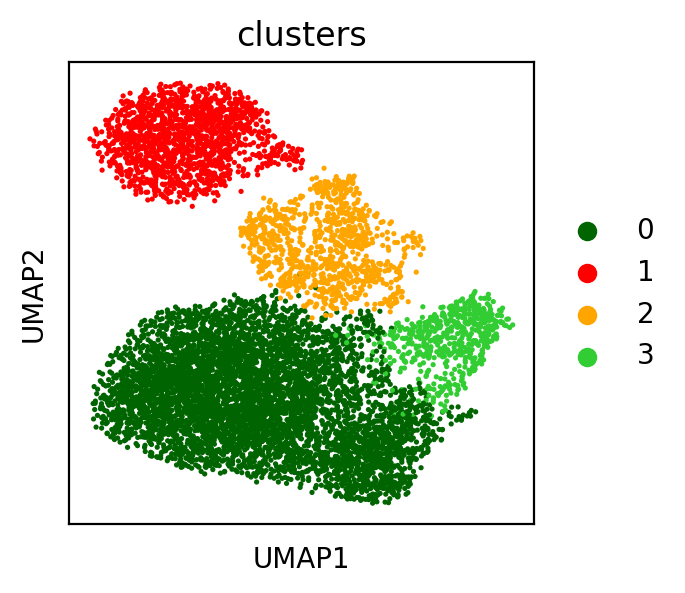

In [4]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3
sc.pl.umap(adata, color='clusters')

# Load tabula sapiens

In [5]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/adaptive_sampling/data/tabula_sapiens_filtered.h5ad"
sdf = sc.read_h5ad(fpath)

sc.pp.normalize_total(sdf, target_sum=1e6)

sdf

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 27346 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'celltype', 'record_id', 'cell_id'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'log1p', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

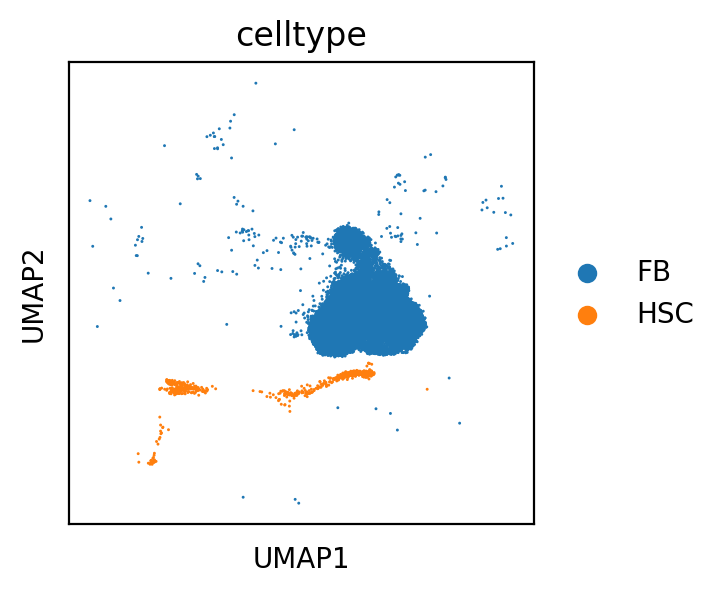

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3
sc.pl.umap(sdf, color='celltype')

In [7]:
sdf.obs[['celltype', 'organ_tissue']].value_counts()

celltype  organ_tissue   
FB        Fat                8459
          Vasculature        5867
          Bladder            5557
          Thymus             3924
          Trachea            1239
          Large_Intestine     953
HSC       Bone_Marrow         617
FB        Tongue              251
          Prostate            223
          Small_Intestine     113
HSC       Spleen               73
          Blood                70
dtype: int64

# Marker genes

In [8]:
def getGenes(pdf, cellType, ui_upper=None):
    genes = pdf[pdf['cell type'] == cellType]
    
    if not ui_upper is None:
        genes = genes[genes['ubiquitousness index'] < ui_upper]
    return genes['official gene symbol'].to_list()


pdfPath = "/nfs/turbo/umms-indikar/shared/projects/spatial_transcriptomics/data/panglaodb/pandb.tsv.gz"
pandDf = pd.read_csv(pdfPath, sep="\t")

fb = getGenes(pandDf, 'Fibroblasts')
hp = getGenes(pandDf, 'Hematopoietic stem cells')

print(f"FB genes: {len(fb)}")
print(f"HP genes: {len(hp)}")

FB genes: 179
HP genes: 88


# get minimal overlapping gene set

In [9]:

ref_genes = sdf.var.copy()
data_genes = adata.var.copy()
data_genes = data_genes.reset_index(drop=False)


gene_df = pd.merge(data_genes[['gene_name', 'gene_id']],
                   ref_genes[['gene_symbol',]],
                   how='left',
                   left_on='gene_name',
                   right_on='gene_symbol')

gene_df['is_fb_marker'] = np.where(gene_df['gene_name'].isin(fb), True, False)
gene_df['is_hsc_marker'] = np.where(gene_df['gene_name'].isin(hp), True, False)

print(gene_df['is_fb_marker'].value_counts())
print()
print(gene_df['is_hsc_marker'].value_counts())
print()

gene_df.head()

False    14644
True       135
Name: is_fb_marker, dtype: int64

False    14708
True        71
Name: is_hsc_marker, dtype: int64



,gene_name,gene_id,gene_symbol,is_fb_marker,is_hsc_marker
0,ATAD3B,ENSG00000160072,ATAD3B,False,False
1,SKI,ENSG00000157933,SKI,False,False
2,PEX14,ENSG00000142655,PEX14,False,False
3,PLCH2,ENSG00000149527,PLCH2,False,False
4,SPSB1,ENSG00000171621,SPSB1,False,False


# combine data sets

In [10]:
def extract_objects(adata, sdf, gene_list):    
    our_data = adata[:, gene_list['gene_id'].to_list()]
    ref_data = sdf[:, gene_list['gene_symbol'].to_list()]
    return our_data, ref_data

def merge_counts(adata, sdf, gene_list, raw=True, sample=None):
    """A function to build a new anndata 
    object with the raw counts from both datasets """
    print(f"Using {gene_list.shape[0]} genes...")

    our_data, ref_data = extract_objects(adata, sdf, gene_list)

    if raw:
        print(f"extracting raw counts...")
        our_df = our_data.to_df(layer='counts')
        ref_df = ref_data.to_df(layer='raw_counts')
    else:
        our_df = our_data.to_df()
        ref_df = ref_data.to_df()
        
    # standardize the column names
    our_df.columns = gene_list['gene_name'].to_list()
    ref_df.columns = gene_list['gene_name'].to_list()
    
    # merge expression data
    data_df = pd.concat([our_df, ref_df])
    
    print(f"{our_df.shape=}")
    print(f"{ref_df.shape=}")
    print(f"{data_df.shape=}")

    # get observation data
    our_obs = our_data.obs.copy()
    our_obs['set'] = 'our_data'
    our_obs = our_obs[['cluster_name','set', 'UMAP 1', 'UMAP 2']]
    
    ref_obs = ref_data.obs.copy()
    ref_obs['set'] = 'ref_data'
    ref_obs = ref_obs[['organ_tissue', 'set', 'celltype']]
    
    # merge obs data
    obs_data = pd.concat([our_obs, ref_obs])
    
    print()
    print(f"{obs_data.shape=}")
    
    var_df = gene_list.copy()
    var_df = var_df.set_index('gene_name')

    print(f"{var_df.shape=}")
    
    data = sc.AnnData(data_df, 
                      var=var_df,
                      obs=obs_data)

    if not sample is None:
        data = sc.pp.subsample(data, fraction=sample, copy=True)

    return data

# all genes
mask = (gene_df['gene_symbol'].notna())
gene_list = gene_df[mask].reset_index(drop=True)

# # random genes
# mask = (gene_df['gene_symbol'].notna())
# gene_list = gene_df[mask].reset_index(drop=True)
# gene_list = gene_list.sample(1000)

data = merge_counts(adata, sdf, gene_list, sample=None)
data

Using 14420 genes...
extracting raw counts...
our_df.shape=(8475, 14420)
ref_df.shape=(27346, 14420)
data_df.shape=(35821, 14420)

obs_data.shape=(35821, 6)
var_df.shape=(14420, 4)


AnnData object with n_obs × n_vars = 35821 × 14420
    obs: 'cluster_name', 'set', 'UMAP 1', 'UMAP 2', 'organ_tissue', 'celltype'
    var: 'gene_id', 'gene_symbol', 'is_fb_marker', 'is_hsc_marker'

# Build merged data

In [24]:
# all genes
mask = (gene_df['gene_symbol'].notna())
gene_list = gene_df[mask].reset_index(drop=True)

data = merge_counts(adata, sdf, gene_list, sample=None)

# annotate raw data
data.layers["raw_counts"] = data.X.copy()

# # sample for testing
# data = sc.pp.subsample(data, n_obs=3000, copy=True)

data

Using 14420 genes...
extracting raw counts...
our_df.shape=(8475, 14420)
ref_df.shape=(27346, 14420)
data_df.shape=(35821, 14420)

obs_data.shape=(35821, 6)
var_df.shape=(14420, 4)


AnnData object with n_obs × n_vars = 35821 × 14420
    obs: 'cluster_name', 'set', 'UMAP 1', 'UMAP 2', 'organ_tissue', 'celltype'
    var: 'gene_id', 'gene_symbol', 'is_fb_marker', 'is_hsc_marker'
    layers: 'raw_counts'

In [25]:
# params
outpath = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/scanpy/anndata_tabula_merged.h5ad"
target_sum = 1e6
diffision = 2
magic_knn = 31
magic_solver = "approximate"

# simple preprocessing
sc.pp.normalize_total(data, target_sum=target_sum)
sc.pp.log1p(data)
data.layers["log_tpm"] = data.X.copy()

# # batch regression
# sc.pp.regress_out(data, keys='set')
# data.layers["batch_regression"] = data.X.copy() + data.X.min()

# batch correction
data.X = data.layers["log_tpm"].copy()
sc.pp.combat(data, key='set',) # regress out batch effects 
X = data.X.copy() 

# shift so min is zero
data.layers["combat_corrected"] = X + np.abs(X.min())

# imputation
sce.pp.magic(data, 
             t=diffision, 
             knn=magic_knn, solver=magic_solver,
             name_list='all_genes')

data.layers["imputed"] = data.X.copy()

# set the default data layer to be batch corrected, rather than imputed
data.X = data.layers["combat_corrected"].copy()

data.write(outpath)

data

normalizing counts per cell
    finished (0:00:00)


... storing 'set' as categorical
... storing 'gene_id' as categorical


Standardizing Data across genes.

Found 2 batches

Found 0 numerical variables:
	

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data

computing MAGIC
    finished (0:10:47)


AnnData object with n_obs × n_vars = 35821 × 14420
    obs: 'cluster_name', 'set', 'UMAP 1', 'UMAP 2', 'organ_tissue', 'celltype'
    var: 'gene_id', 'gene_symbol', 'is_fb_marker', 'is_hsc_marker'
    uns: 'log1p'
    layers: 'raw_counts', 'log_tpm', 'combat_corrected', 'imputed'

In [26]:
data.to_df('raw_counts')[['CD34', 'FOS']].head()

gene_name,CD34,FOS
AAACCCAAGGTTACCT,2.0,0.0
AAACCCAAGTTGAAGT,0.0,0.0
AAACCCAAGTTGTCGT,0.0,0.0
AAACCCACAGAAGCGT,1.0,0.0
AAACCCACAGGAGGTT,0.0,0.0


In [28]:
data.to_df('combat_corrected')[['CD34', 'FOS']].head() 

gene_name,CD34,FOS
AAACCCAAGGTTACCT,36.323003,32.794516
AAACCCAAGTTGAAGT,29.452914,32.794516
AAACCCAAGTTGTCGT,29.452914,32.794516
AAACCCACAGAAGCGT,36.261978,32.794516
AAACCCACAGGAGGTT,29.452914,32.794516


In [29]:
x = data.to_df('combat_corrected')['CD34']
y = data.to_df('raw_counts')['CD34']

scipy.stats.pearsonr(x, y)

PearsonRResult(statistic=0.049250079816211295, pvalue=1.0930148350218866e-20)

In [30]:
np.min(data.to_df('combat_corrected').to_numpy())

0.0

In [ ]:
data.X.min()